In [25]:
import pandas as pd
import numpy as np

In [26]:
df=pd.read_csv("powerplant_data.csv")

In [27]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [28]:
# AT=> Temperature, V=> Volume, AP=> Pressure, RH=> Humidity
# PE=> Produced Energy / Output

In [29]:
df.isnull().sum() #No Null Values Present

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [30]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [31]:
X.head()
# y.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [32]:
# Split the data out

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [33]:
df.shape

(9568, 5)

In [34]:
# Scaling the data

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [35]:
X_train_scaled
# X_test_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [61]:
type(y_train)

pandas.Series

In [36]:
# Creating Tensors/ Converting our data into Tensors

import torch
import torch.nn as nn

X_train_tensor=torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor=torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [37]:
X_train_tensor
# X_test_tensor

tensor([[ 0.7481,  0.7201, -0.3266, -0.4971],
        [ 0.8618,  1.2652, -0.9852,  0.8182],
        [ 0.9341,  1.5231,  0.3252,  0.8017],
        ...,
        [-0.2210, -0.8350,  0.3676, -0.8355],
        [ 0.9475,  1.1425, -0.4197, -0.4546],
        [-1.7736, -1.1905,  1.9252,  0.9184]])

In [38]:
type(X_test_scaled)

numpy.ndarray

In [39]:
type(y_train)
y_train.shape

(7654,)

In [40]:
y_train_tensor
y_train_tensor.shape
# y_test_tensor
# y_test_tensor.shape

torch.Size([7654, 1])

In [41]:
# Creat Batches with the help of TensorDataset and tensor Dataloader for training

from torch.utils.data import TensorDataset, DataLoader

train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

In [42]:
train_loader=DataLoader(train_dataset, batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=32)

In [43]:
print(train_loader)

### Deep Learning

In [44]:
# Defining Our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model=nn.Sequential(
            #1st Hidden Layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            #2nd Hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),

            #Output Layer
            nn.Linear(6,1)
        )

    def forward(self,x):
        return self.model(x)

In [45]:
import torch.optim as optim

# Building Our ANN Model

model=ANN()

# loss, Optimizer
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [46]:
# Training Our ANN Model

training_losses=[]
validation_losses=[]

best_validation_loss=float("inf")

epochs=100

for epoch in range(epochs):
    model.train()
    running_loss=0.0 #Total Training Loss 1 Epoch
    
    for xb,yb in train_loader:
        #xb= Features of 1 batch, yb= Outputs/Labels of 1 batch

        optimizer.zero_grad()
        
        outputs=model(xb) #Forward Propagation...Predicted Outputs for this Batch
        loss=criterion(outputs, yb)  #Computing the loss
        loss.backward()  #Backward Propagation
        optimizer.step() #Updating the Parameters

        running_loss+=loss.item()  #Loss is a tensor value that is converted into a python float value

    epoch_train_loss=running_loss/len(train_loader)
    training_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_validation_loss=0.0

    with torch.no_grad(): # Indicating to not calculate any gradient since it is done automatically using
        for xb,yb in test_loader: #Autograd

            outputs=model(xb) 
            loss=criterion(outputs, yb)

            running_validation_loss+=loss.item() 

        epoch_validation_loss=running_validation_loss/len(test_loader)
        validation_losses.append(epoch_validation_loss)

        print(f"Epoch {epoch+1}/{epochs} ==> Training Loss = {epoch_train_loss} & Validation Loss = {epoch_validation_loss}")

        if epoch_validation_loss<best_validation_loss:
            best_validation_loss=epoch_validation_loss
            torch.save(model.state_dict(), "best_model.pt") # .pt or .pth

Epoch 1/100 ==> Training Loss = 205881.40364583334 & Validation Loss = 203430.496875
Epoch 2/100 ==> Training Loss = 194174.79837239583 & Validation Loss = 179172.8078125
Epoch 3/100 ==> Training Loss = 153693.24241536457 & Validation Loss = 123852.31171875
Epoch 4/100 ==> Training Loss = 92042.20260416667 & Validation Loss = 63025.08255208333
Epoch 5/100 ==> Training Loss = 43632.17154541016 & Validation Loss = 30306.011881510418
Epoch 6/100 ==> Training Loss = 24677.322102864582 & Validation Loss = 21000.552083333332
Epoch 7/100 ==> Training Loss = 19036.174747721354 & Validation Loss = 17110.921940104166
Epoch 8/100 ==> Training Loss = 15591.775443522136 & Validation Loss = 13807.921232096354
Epoch 9/100 ==> Training Loss = 12371.603251139322 & Validation Loss = 10698.102596028646
Epoch 10/100 ==> Training Loss = 9365.65406697591 & Validation Loss = 7808.261450195312
Epoch 11/100 ==> Training Loss = 6641.72282409668 & Validation Loss = 5310.291174316406
Epoch 12/100 ==> Training Los

In [47]:
import matplotlib.pyplot as plt

loss_df=pd.DataFrame({
    "Training Loss": training_losses,
    "Validation Loss":validation_losses
})

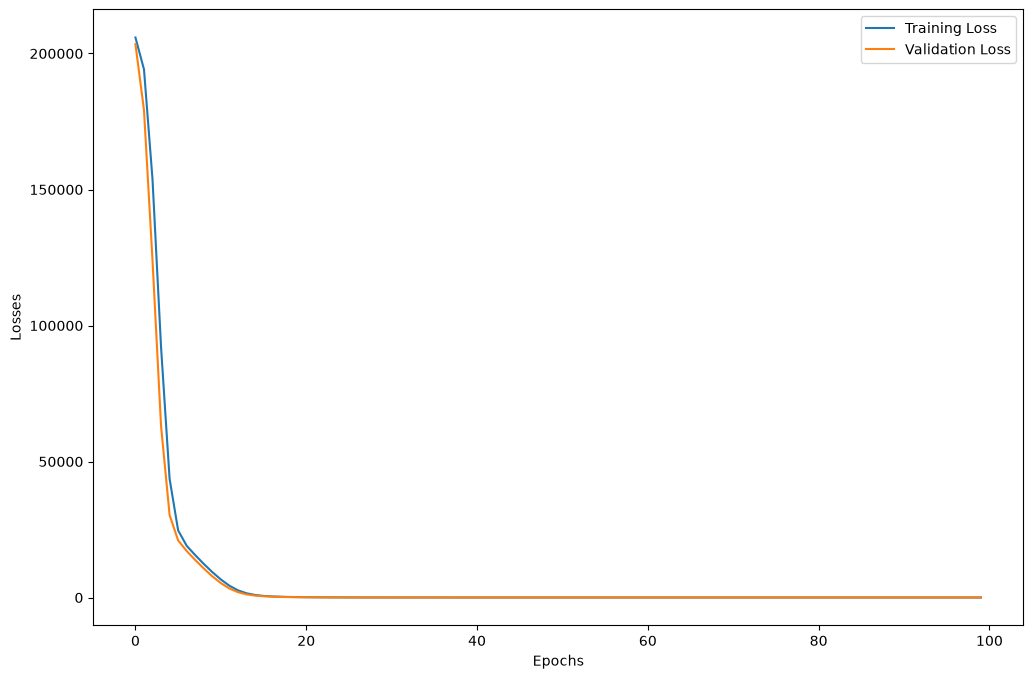

In [48]:
#Plotting The Losses

plt.figure(figsize=(12,8))

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")



plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [49]:
# Retrieving the best parametrs or Loading the best model

model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [51]:
# Evaluate or Testing our Model

model.eval()

with torch.no_grad():
    train_preds=model(X_train_tensor)
    test_preds=model(X_test_tensor)

    train_mse_loss=criterion(train_preds, y_train_tensor)
    test_mse_loss=criterion(test_preds, y_test_tensor)

print("Training MSE:",train_mse_loss.item())
print("Testing MSE:",test_mse_loss.item())

Training MSE: 19.93806266784668
Testing MSE: 18.442523956298828


In [52]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, test_preds))

R2 Score: 0.93554813507804


In [55]:
predicted_df=pd.DataFrame(test_preds.numpy(), columns=["Predicted Value"])
actual_df=pd.DataFrame(y_test.values, columns=["Actual Value"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Value,Actual Value
0,434.984344,433.27
1,436.817413,438.16
2,461.248077,458.42
3,475.913055,480.82
4,435.462128,441.41
...,...,...
1909,451.660889,456.70
1910,431.613983,438.04
1911,467.781097,467.80
1912,431.115448,437.14
